In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(os.path.abspath(".."))
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path(os.path.abspath("."))

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

In [2]:
RESEARCH_DATASET_DIR = (PROJECT_ROOT / "data" / "research_processed_smoke_auto").resolve()
RESEARCH_MODEL_DIR = (PROJECT_ROOT / "models" / "research_smoke_auto").resolve()
RESEARCH_RESULTS_DIR = (PROJECT_ROOT / "results" / "research_smoke_auto").resolve()

# 02 Train

This notebook trains the FiLM-conditioned autoencoder on the research smoke dataset
and saves checkpoints under `models/research_smoke_auto/`.

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import torch

from src.config import TrainConfig
from src.dataset import load_dataset
from src.model import FiLMAutoencoder
from src.train import load_processed_dataset, split_by_metadata, train_model
from src.utils import read_json

## Load Processed Dataset

In [4]:
cfg = TrainConfig(
    dataset_dir=RESEARCH_DATASET_DIR,
    model_dir=RESEARCH_MODEL_DIR,
    epochs=20,
    batch_size=128,
    patience=8,
)
dataset_bundle = load_processed_dataset(cfg.dataset_dir)
dataset_bundle["X"].shape, dataset_bundle["C"].shape

((1942104, 30, 8), (1942104, 17))

In [5]:
split_bundle = split_by_metadata(
    dataset_bundle["X"],
    dataset_bundle["C"],
    dataset_bundle["metadata"],
)
{
    split_name: {
        "X": split_data[0].shape,
        "C": split_data[1].shape,
        "rows": len(split_data[2]),
    }
    for split_name, split_data in split_bundle.items()
}

{'train': {'X': (1549423, 30, 8), 'C': (1549423, 17), 'rows': 1549423},
 'val': {'X': (0, 30, 8), 'C': (0, 17), 'rows': 0},
 'test': {'X': (392681, 30, 8), 'C': (392681, 17), 'rows': 392681}}

## Initialize FiLM Autoencoder

In [6]:
x_train, c_train, _ = split_bundle["train"]
model = FiLMAutoencoder(
    window_size=x_train.shape[1],
    n_features=x_train.shape[2],
    context_dim=c_train.shape[1],
    units=cfg.units,
    latent=cfg.latent,
)
model

FiLMAutoencoder(
  (encoder_block_1): FiLMBlock(
    (conv): Conv1d(8, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (film): FiLM(
      (modulation): Linear(in_features=17, out_features=128, bias=True)
    )
    (activation): ReLU()
  )
  (encoder_block_2): FiLMBlock(
    (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (film): FiLM(
      (modulation): Linear(in_features=17, out_features=128, bias=True)
    )
    (activation): ReLU()
  )
  (global_pool): AdaptiveAvgPool1d(output_size=1)
  (latent_projection): Linear(in_features=64, out_features=64, bias=True)
  (decoder_dense): Linear(in_features=64, out_features=1920, bias=True)
  (decoder_block): FiLMBlock(
    (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (film): FiLM(
      (modulation): Linear(in_features=17, out_features=128, bias=True)
    )
    (activation): ReLU()
  )
  (decoder_conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (decoder_activation): R

## Training Loop, Validation Loop, And Checkpoint Save

In [7]:
train_summary = train_model(cfg)
train_summary

Train Epoch 1/20:   0%|          | 0/10895 [00:00<?, ?it/s]

Val Epoch 1/20:   0%|          | 0/1211 [00:00<?, ?it/s]

Epoch [1/20] - Loss: 0.2653 - Val Loss: 0.6653


Train Epoch 2/20:   0%|          | 0/10895 [00:00<?, ?it/s]

Val Epoch 2/20:   0%|          | 0/1211 [00:00<?, ?it/s]

...

Epoch [19/20] - Loss: 0.0835 - Val Loss: 0.4474


Train Epoch 20/20:   0%|          | 0/10895 [00:00<?, ?it/s]

Val Epoch 20/20:   0%|          | 0/1211 [00:00<?, ?it/s]

Epoch [20/20] - Loss: 0.0825 - Val Loss: 0.4448
Final training loss: 0.0825
Saved loss curve to: C:\Users\kaspe\Desktop\Project\project\results\loss_curve.png


{'model_dir': 'C:\\Users\\kaspe\\Desktop\\Project\\project\\models\\research_smoke_auto',
 'history_path': 'C:\\Users\\kaspe\\Desktop\\Project\\project\\models\\research_smoke_auto\\training_history.csv',
 'loss_curve_path': 'C:\\Users\\kaspe\\Desktop\\Project\\project\\results\\loss_curve.png',
 'model_path': 'C:\\Users\\kaspe\\Desktop\\Project\\project\\models\\research_smoke_auto\\film_ae.pt',
 'detector_meta': {'threshold': 4.4031548500061035,
  'threshold_quantile': 0.995,
  'window_size': 30,
  'n_features': 8,
  'context_dim': 17,
  'score_mode': 'mean_feature_mse',
  'num_train_windows': 1394481,
  'num_val_windows': 154942,
  'num_test_windows': 392681,
  'best_val_loss': 0.44475893890678353,
  'val_score_mean': 0.44475892186164856,
  'val_score_std': 0.6830311417579651,
  'test_split_rows': 392681},
 'train_config': {'dataset_dir': 'C:\\Users\\kaspe\\Desktop\\Project\\project\\data\\research_processed_smoke_auto',
  'model_dir': 'C:\\Users\\kaspe\\Desktop\\Project\\project\\m

## Plot Losses

In [8]:
history = pd.read_csv(cfg.model_dir / "training_history.csv")
history.tail()

,epoch,train_loss,val_loss,lr,epoch_seconds,improved
15,16,0.252114,0.475074,0.0010,590.749665,False
16,17,0.086283,0.475595,0.0010,585.437444,False
17,18,0.170799,0.462559,0.0005,582.743409,False
18,19,0.083536,0.447434,0.0005,584.700510,True
19,20,0.082531,0.444759,0.0005,587.041119,True


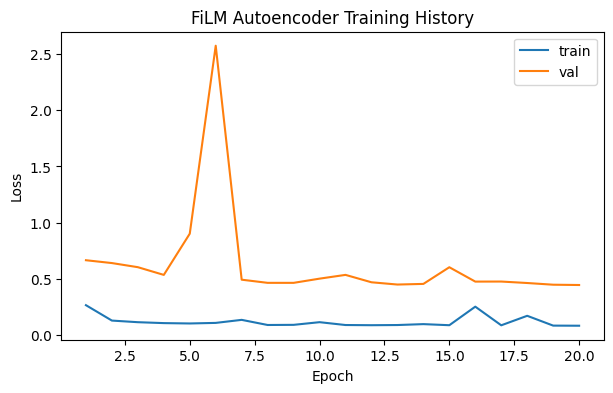

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(history["epoch"], history["train_loss"], label="train")
plt.plot(history["epoch"], history["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("FiLM Autoencoder Training History")
plt.legend()
plt.show()

## Threshold Fitting

In [10]:
detector_meta = read_json(cfg.model_dir / "detector_meta.json")
detector_meta

{'threshold': 4.4031548500061035,
 'threshold_quantile': 0.995,
 'window_size': 30,
 'n_features': 8,
 'context_dim': 17,
 'score_mode': 'mean_feature_mse',
 'num_train_windows': 1394481,
 'num_val_windows': 154942,
 'num_test_windows': 392681,
 'best_val_loss': 0.44475893890678353,
 'val_score_mean': 0.44475892186164856,
 'val_score_std': 0.6830311417579651,
 'test_split_rows': 392681}